# Identifikasi Kategori Penyumbang Loss

Analisis difokuskan pada bulan dengan profit margin terendah yang telah diidentifikasi sebelumnya.

## Metodologi

1. Memfilter transaksi pada bulan April 2017.
2. Menghitung total `profit` dan `sales` per kategori.
3. Menghitung `profit_margin` per kategori.
4. Memvisualisasikan `profit_margin` per kategori.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

# load data
df = pd.read_pickle('superstore.pkl')

# order_date
order_str = df['order_date'].map(lambda x: type(x) == str)
order_no_str = df['order_date'].map(lambda x: type(x) != str)

df.loc[order_str, 'order_date'] = df.loc[order_str, 'order_date'].map(lambda x: '-'.join([i.zfill(2) for i in x.split('/')]))
df.loc[order_no_str, 'order_date'] = (df.loc[order_no_str, 'order_date'].astype(str)
                                      .map(lambda x: '-'.join(x.split()[0].split('-')[::-1])))
df['order_date'] = pd.to_datetime(df['order_date'], format='%m-%d-%Y', errors='coerce')

# ship_date
ship_str = df['ship_date'].map(lambda x: type(x) == str)
ship_no_str = df['ship_date'].map(lambda x: type(x) != str)

df.loc[ship_str, 'ship_date'] = df.loc[ship_str, 'ship_date'].map(lambda x: '-'.join([i.zfill(2) for i in x.split('/')]))
df.loc[ship_no_str, 'ship_date'] = (df.loc[ship_no_str, 'ship_date'].astype(str)
                                    .map(lambda x: '-'.join(x.split()[0].split('-')[::-1])))
df['ship_date'] = pd.to_datetime(df['ship_date'], format='%m-%d-%Y', errors='coerce')

# order_month
month = ['January', 'February', 'March', 'April', 'May', 'June',
         'July', 'August', 'September', 'October', 'November', 'December']
df['order_month'] = pd.Categorical(df['order_date'].dt.strftime('%B'), categories=month, ordered=True)

# order_year
df['order_year'] = df['order_date'].dt.year

## Filter Data April 2017

Data difokuskan pada transaksi bulan April 2017 sebagai bulan dengan profit margin terendah.

In [2]:
df_april = df[(df['order_year'] == 2017) & (df['order_month'] == 'April')]

## Hitung Total Profit dan Sales per Kategori

Data dikelompokkan berdasarkan `category`, lalu dihitung total `profit` dan `sales` untuk setiap kategori.

In [3]:
df_agg = df_april.pivot_table(index='category', values=['profit', 'sales'], aggfunc='sum')

df_agg

,profit,sales
category,,
Furniture,202.4624,9065.9581
Office Supplies,3370.6015,15072.1910
Technology,-2639.7739,12383.3870


## Hitung Profit Margin

Profit margin dihitung dengan membagi `profit` terhadap `sales`, lalu dikalikan 100 untuk memperoleh persentase.

In [4]:
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

,profit,sales,profit_margin
category,,,
Furniture,202.4624,9065.9581,2.233216
Office Supplies,3370.6015,15072.1910,22.363049
Technology,-2639.7739,12383.3870,-21.317059


## Visualisasi Profit Margin per Kategori

Menampilkan `profit_margin` per kategori pada bulan April 2017.

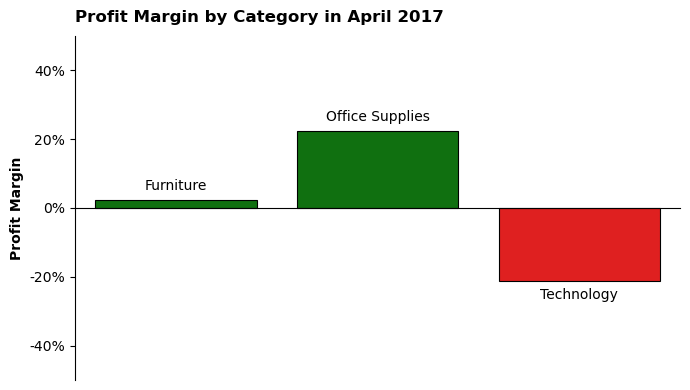

In [5]:
plt.figure(figsize=(7,4))
palette = ['red' if margin < 0 else 'green' for margin in df_agg['profit_margin']]
sns.barplot(x=df_agg.index, y=df_agg['profit_margin'], palette=palette, ls='-', lw=0.8, ec='black', alpha=1)

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'rotation':0,
              'pad':10,
              'alpha':1,
              'family':plt.rcParams['font.family']}

label_dict = {'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1,
              'family':plt.rcParams['font.family']}}

plt.title('Profit Margin by Category in April 2017', **title_dict)
plt.xlabel('')
plt.ylabel('Profit Margin', **label_dict['y'])

ax = plt.gca()
ax.spines['bottom'].set_position(('data', 0))
ax.tick_params(which='major', axis='both', color='black', direction='out', left=True, bottom=False)
ax.set_xticklabels('')
container = ax.containers[0]
labels = df_agg.index.tolist()
ax.bar_label(container=container, labels=labels, size=10, weight='normal', color='black', padding=5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{int(y)}%'))
ax.set_ylim(-50, 50)

plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()